# Segmentación de clientes mediante K-Means

**Asignatura:** Inteligencia Artificial  
**Estudiante:** Mejía Jefferson  
**Técnica:** aprendizaje no supervisado

## 1. Introducción

La segmentación de clientes permite identificar grupos con características y hábitos de consumo similares. En este cuaderno se presenta un ejercicio académico de aprendizaje no supervisado usando K-Means para explorar esos grupos sin disponer de etiquetas previas.

## 2. Planteamiento del problema

Una empresa desea conocer los perfiles de sus clientes para adaptar campañas, promociones y estrategias de fidelización. Sin embargo, no dispone de una etiqueta previa que indique a qué segmento pertenece cada cliente. Por ello, se requiere descubrir grupos naturales a partir de sus características demográficas y de consumo.

## 3. Objetivos

**Objetivo general:** Aplicar **K-Means** para agrupar clientes con características similares de edad, ingreso mensual y gasto mensual, e interpretar los segmentos obtenidos para apoyar decisiones comerciales.

## 4. Marco teórico

K-Means es un algoritmo de aprendizaje no supervisado que asigna cada observación al centroide más cercano y busca minimizar la suma de cuadrados dentro de los grupos (inercia). No utiliza una variable objetivo ni etiquetas conocidas.

El método fue propuesto por Stuart Lloyd (1957; publicado en 1982) y popularizado por James MacQueen (1967). Debido a que K-Means depende de distancias, las variables se estandarizan antes de ajustar el modelo.


## 5. Descripción de los datos

El conjunto de datos contiene 120 observaciones de clientes. Para este ejercicio se emplean variables demográficas y de consumo que permiten explorar la segmentación.


### 5.1. Variables analizadas

- **Edad:** años del cliente.
- **Ingreso mensual:** ingreso estimado en dólares.
- **Gasto mensual:** gasto estimado en dólares.


### 5.2. Procedencia y alcance de los datos

Los datos fueron generados de forma sintética para practicar la metodología; no corresponden a clientes reales. Por tanto, los resultados ilustran el proceso de segmentación, pero no deben convertirse directamente en decisiones comerciales. Con datos reales se debería revisar valores faltantes, duplicados y valores atípicos antes del modelado.

## 6. Metodología

La metodología se evalúa a partir de las salidas obtenidas, no solo de la ejecución del algoritmo. El análisis debe leerse con una reserva central: los datos se fabricaron a partir de cuatro perfiles definidos de antemano y K-Means terminó recuperando cuatro grupos. Por ello, el resultado demuestra que el procedimiento reconoce una estructura deliberadamente incorporada en los datos, pero todavía no demuestra que existan cuatro segmentos naturales en una población real.

### 6.1. Importación de librerías

NumPy genera los valores numéricos del conjunto sintético; pandas organiza los 120 registros en una tabla; Matplotlib construye el gráfico del codo y la visualización de segmentos; `StandardScaler` iguala la escala de edad, ingreso y gasto; `KMeans` calcula las agrupaciones. La paleta de seis colores y la resolución de 110 dpi mantienen el mismo formato visual en todas las figuras.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Identidad visual centralizada para las figuras del informe.
COLOR_PRINCIPAL = "#2563EB"
COLOR_DESTACADO = "#F97316"
COLOR_OSCURO = "#0F172A"
PALETA_CLUSTERS = ["#4E79A7", "#59A14F", "#E15759", "#B07AA1", "#F28E2B", "#76B7B2"]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.labelcolor": "#334155",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "#CBD5E1",
})


### 6.2. Generación del conjunto de datos

Se generaron 120 registros distribuidos en cuatro perfiles prefijados de 30 casos; la salida presentó edades de 18 a 66 años, ingresos de USD 0 a USD 8.487,92 y gastos de USD 0 a USD 3.495,37. El reparto exacto de 30 casos anticipa cuatro grupos equilibrados y reduce la dificultad del agrupamiento. El recorte de valores negativos creó montos de USD 0 que pueden desplazar los centroides. Además, NumPy no tiene una semilla fija: una nueva ejecución cambiará datos, inercias y centroides, dado que `random_state=42` controla K-Means pero no la generación inicial.

In [2]:
# Perfiles sintéticos: jóvenes de bajo gasto, clientes regulares,
# clientes de alto valor y clientes maduros con gasto moderado.
perfiles = [
    (24, 1700, 300),
    (35, 3600, 1100),
    (43, 7200, 2700),
    (58, 5000, 1500),
]

datos = []
for edad_media, ingreso_medio, gasto_medio in perfiles:
    datos.append(np.column_stack([
        np.random.normal(edad_media, 4, 30),
        np.random.normal(ingreso_medio, 700, 30),
        np.random.normal(gasto_medio, 250, 30),
    ]))

clientes = pd.DataFrame(
    np.vstack(datos), columns=["Edad", "Ingreso mensual", "Gasto mensual"]
)
clientes["Edad"] = clientes["Edad"].round().clip(18, 70).astype(int)
clientes[["Ingreso mensual", "Gasto mensual"]] = clientes[
    ["Ingreso mensual", "Gasto mensual"]
].clip(lower=0).round(2)

clientes.head()

,Edad,Ingreso mensual,Gasto mensual
0,18,1732.00,29.16
1,22,2191.32,144.28
2,23,1284.72,207.40
3,24,1891.33,636.86
4,26,1493.62,362.14


### 6.3. Preparación de los datos

`StandardScaler` llevó edad, ingreso y gasto a media cero con desviación estándar uno; este ajuste evitó que el ingreso, cuyo máximo fue USD 8.487,92, dominara a la edad, cuyo máximo fue 66. El procedimiento asignó el mismo peso a las tres variables sin justificarlo mediante criterios comerciales. Tampoco se cuantificaron valores atípicos ni la correlación entre ingreso y gasto; una correlación alta representaría dos veces la capacidad económica y aumentaría su influencia sobre las distancias.

In [11]:
variables = ["Edad", "Ingreso mensual", "Gasto mensual"]
X = clientes[variables]
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

### 6.4. Selección del número de grupos: método del codo

La inercia bajó de 140,69 con `k=2` a 70,64 con `k=3` y 32,82 con `k=4`, reducciones de 49,79 % y 53,55 %; luego descendió solamente 11,45 % con `k=5` y 10,57 % con `k=6`. El cambio respalda `k=4`, resultado que también obtuvo el criterio geométrico. Esta coincidencia no basta para validar cuatro segmentos: los datos fueron construidos desde cuatro perfiles y la inercia disminuye automáticamente al añadir clusters. Faltan el índice *silhouette*, pruebas de estabilidad y ejecuciones con distintas semillas para medir separación y consistencia.

In [ ]:
resultados_k = []
#range
for k in range(2, 7):
    modelo = KMeans(n_clusters=k, n_init=20, random_state=42)
    modelo.fit(X_escalado)
    resultados_k.append({"k": k, "Inercia": modelo.inertia_})

evaluacion = pd.DataFrame(resultados_k)
evaluacion


,k,Inercia
0,2,140.691703
1,3,70.640195
2,4,32.815358
3,5,29.058050
4,6,25.987997


In [5]:
# Se identifica el punto más alejado de la recta entre los extremos de la curva.
# Es una aproximación automática y reproducible del "codo".
k_valores = evaluacion["k"].to_numpy(dtype=float)
inercia = evaluacion["Inercia"].to_numpy(dtype=float)
puntos = np.column_stack((
    (k_valores - k_valores.min()) / (k_valores.max() - k_valores.min()),
    (inercia - inercia.min()) / (inercia.max() - inercia.min()),
))
inicio, fin = puntos[0], puntos[-1]
vector_linea = fin - inicio
vectores_puntos = puntos - inicio
distancias = np.abs(
    vector_linea[0] * vectores_puntos[:, 1] - vector_linea[1] * vectores_puntos[:, 0]
) / np.linalg.norm(vector_linea)
k_optimo = int(k_valores[np.argmax(distancias)])

print(f"Valor de k sugerido por el método del codo: {k_optimo}")


Valor de k sugerido por el método del codo: 4


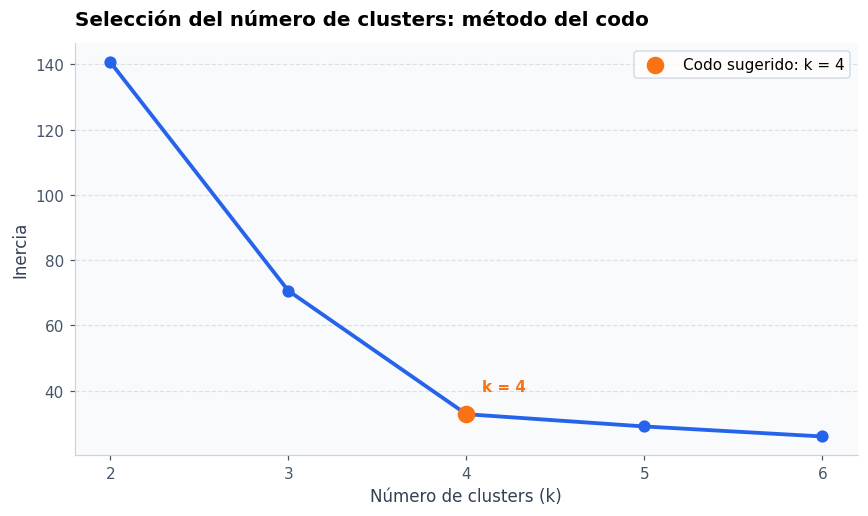

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(
    evaluacion["k"], evaluacion["Inercia"],
    marker="o", markersize=7, linewidth=2.5, color=COLOR_PRINCIPAL
)
ax.scatter(k_optimo, evaluacion.loc[evaluacion["k"] == k_optimo, "Inercia"],
           s=110, color=COLOR_DESTACADO, zorder=3, label=f"Codo sugerido: k = {k_optimo}")
ax.annotate(
    f"k = {k_optimo}",
    xy=(k_optimo, evaluacion.loc[evaluacion["k"] == k_optimo, "Inercia"].iloc[0]),
    xytext=(10, 15), textcoords="offset points", color=COLOR_DESTACADO, fontweight="bold"
)
ax.set_title("Selección del número de clusters: método del codo", loc="left", pad=12)
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia")
ax.set_xticks(evaluacion["k"])
ax.grid(axis="y", alpha=0.35, linestyle="--")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(loc="best")
fig.tight_layout()
plt.show()


### 6.5. Ajuste de K-Means

Con `k=4`, cada cluster recibió exactamente 30 clientes. Los centroides fueron: cluster 2, 23,03 años, USD 1.736,30 de ingreso y USD 346,84 de gasto; cluster 0, 33,67 años, USD 3.851,46 y USD 1.202,52; cluster 1, 58,70 años, USD 4.927,75 y USD 1.475,56; cluster 3, 42,33 años, USD 7.330,75 y USD 2.718,61. Las 20 inicializaciones redujeron el riesgo de una solución local deficiente, pero el reparto perfecto reproduce el diseño inicial y no demuestra calidad. Los números de cluster son etiquetas arbitrarias; los nombres de gasto fueron asignados después del ajuste.

In [7]:
k = k_optimo
modelo_final = KMeans(n_clusters=k, n_init=20, random_state=42)
clientes["Cluster"] = modelo_final.fit_predict(X_escalado)

orden_gasto = clientes.groupby("Cluster")["Gasto mensual"].mean().sort_values().index.tolist()
nombres_perfiles = {
    cluster: f"Perfil de gasto {posicion + 1}"
    for posicion, cluster in enumerate(orden_gasto)
}

centroides = pd.DataFrame(
    escalador.inverse_transform(modelo_final.cluster_centers_), columns=variables
)
centroides.index.name = "Cluster"
centroides.round(2)

,Edad,Ingreso mensual,Gasto mensual
Cluster,,,
0,33.67,3851.46,1202.52
1,58.70,4927.75,1475.56
2,23.03,1736.30,346.84
3,42.33,7330.75,2718.61


## 7. Resultados

La solución obtenida separa un perfil joven de bajo gasto, dos perfiles intermedios que se distinguen sobre todo por edad y un perfil de mayor ingreso y gasto. Esta lectura resume lo observado, pero no convierte los clusters en categorías comerciales comprobadas: son agrupaciones descriptivas construidas sobre datos sintéticos.

### 7.1. Prueba con datos ingresados por el usuario

Esta prueba solicita los datos de un cliente, aplica la misma estandarización utilizada durante el entrenamiento y muestra el perfil de gasto asignado por el modelo.

In [ ]:
# Ingreso manual de un cliente para probar el modelo entrenado.
edad_usuario = int(input("Ingrese la edad del cliente: "))
ingreso_usuario = float(input("Ingrese el ingreso mensual (USD): "))
gasto_usuario = float(input("Ingrese el gasto mensual (USD): "))

cliente_prueba = pd.DataFrame([[
    edad_usuario, ingreso_usuario, gasto_usuario
]], columns=variables)

cliente_prueba_escalado = escalador.transform(cliente_prueba)
cluster_predicho = int(modelo_final.predict(cliente_prueba_escalado)[0])
perfil_predicho = nombres_perfiles[cluster_predicho]

print(f"\nCluster asignado: {cluster_predicho}")
print(f"Segmento asignado: {perfil_predicho}")

### 7.2. Visualización de los segmentos

La proyección edad–gasto ubica el perfil 1 en la zona inferior y el perfil 4 en la superior; los perfiles 2 y 3 tienen gastos medios cercanos, USD 1.202,52 y USD 1.475,56, pero edades medias distantes, 33,67 y 58,70 años. Esa diferencia confirma la participación de la edad en la separación. La figura omite el ingreso utilizado por K-Means, por tanto no permite medir la separación completa de los clusters ni sustituye una métrica cuantitativa.

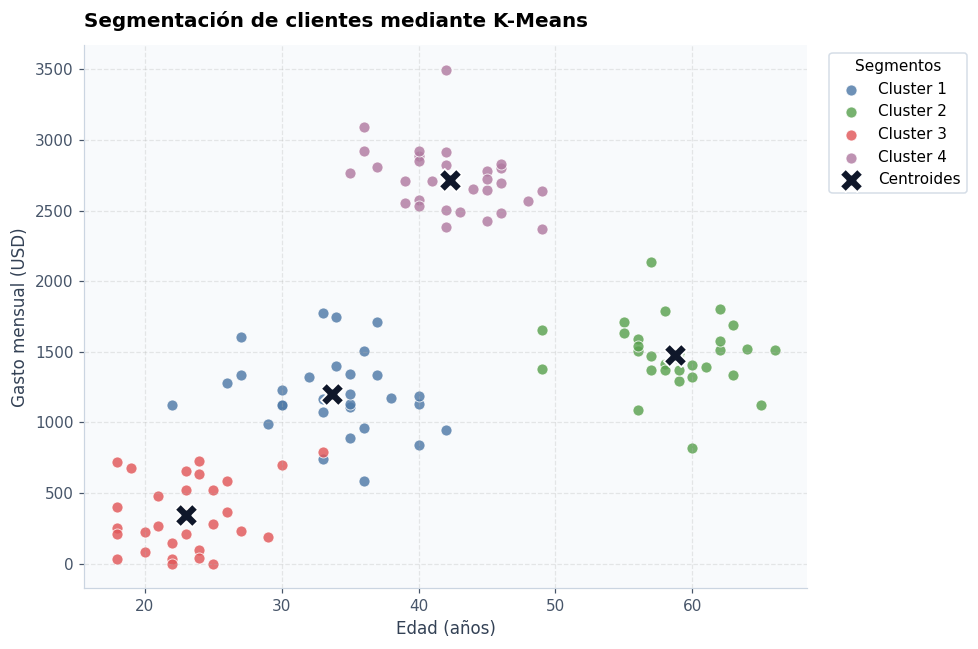

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
paleta = PALETA_CLUSTERS[:k]
clusters_ordenados = sorted(clientes["Cluster"].unique())
color_por_cluster = dict(zip(clusters_ordenados, paleta))

for cluster in clusters_ordenados:
    color = color_por_cluster[cluster]
    grupo = clientes[clientes["Cluster"] == cluster]
    ax.scatter(
        grupo["Edad"], grupo["Gasto mensual"], s=52, alpha=0.82,
        color=color, edgecolor="white", linewidth=0.6,
        label=nombres_perfiles[cluster]
    )

ax.scatter(
    centroides["Edad"], centroides["Gasto mensual"],
    c=COLOR_OSCURO, marker="X", s=230, edgecolor="white", linewidth=1.2,
    label="Centroides", zorder=4
)

# Se destaca el cliente ingresado con el color del cluster predicho.
ax.scatter(
    cliente_prueba.loc[0, "Edad"], cliente_prueba.loc[0, "Gasto mensual"],
    color=color_por_cluster[cluster_predicho], marker="*", s=320,
    edgecolor=COLOR_OSCURO, linewidth=1.4,
    label=f"Cliente de prueba ({perfil_predicho})", zorder=5
)
ax.set_title("Segmentación de clientes mediante K-Means", loc="left", pad=12)
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Gasto mensual (USD)")
ax.grid(alpha=0.28, linestyle="--")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(title="Segmentos", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()


### 7.3. Perfiles de clientes

La tabla muestra gastos medios de USD 346,84, USD 1.202,52, USD 1.475,56 y USD 2.718,61. El cluster 3 presenta el mayor ingreso y gasto, pero no puede clasificarse como el más rentable porque faltan margen, frecuencia, permanencia, deuda y costo de atención. Los clusters 0 y 1 se distinguen principalmente por edad, 33,67 frente a 58,70 años, no por una brecha amplia de gasto. Los 30 clientes presentes en cada grupo proceden del reparto inicial y no constituyen un hallazgo del algoritmo.

In [9]:
resumen = clientes.groupby("Cluster")[variables].mean().round(2)
resumen["Cantidad de clientes"] = clientes.groupby("Cluster").size()

# Los perfiles se ordenan por gasto promedio; su interpretación final se realiza
# después de revisar los resultados obtenidos.
resumen["Perfil propuesto"] = resumen.index.map(nombres_perfiles)
resumen = resumen[["Perfil propuesto", "Cantidad de clientes", *variables]]
resumen


,Perfil propuesto,Cantidad de clientes,Edad,Ingreso mensual,Gasto mensual
Cluster,,,,,
0,Perfil de gasto 2,30,33.67,3851.46,1202.52
1,Perfil de gasto 3,30,58.70,4927.75,1475.56
2,Perfil de gasto 1,30,23.03,1736.30,346.84
3,Perfil de gasto 4,30,42.33,7330.75,2718.61


## 8. Conclusiones

- El método del codo seleccionó `k = 4`. La inercia descendió de 140.69 (`k=2`) a 32.82 (`k=4`); después presentó reducciones menores.
- Los grupos se diferenciaron por ingreso y gasto. El cluster 3 registró los mayores promedios; el cluster 2 presentó los menores.
- La segmentación separó un perfil joven de bajo gasto, dos perfiles de gasto intermedio y un perfil de alto valor. Esta clasificación permite orientar acciones distintas por grupo, pero no demuestra causalidad. La distribución de 30 casos por cluster responde a datos sintéticos.


## 9. Recomendaciones

- Se recomienda aplicar el modelo sobre datos reales con revisión de valores faltantes, duplicados y atípicos.
- Conviene contrastar `k = 4` con métricas de separación y estabilidad de los clusters.
- Resulta necesario validar los perfiles con el área comercial antes de definir campañas diferenciadas.


## 10. Referencias bibliográficas

Lloyd, S. (1982). *Least squares quantization in PCM*. IEEE Transactions on Information Theory, 28(2), 129–137. https://doi.org/10.1109/TIT.1982.1056489

MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability. https://projecteuclid.org/euclid.bsmsp/1200512992
